The training and test data can be downloaded from the following Kaggle competition: https://www.kaggle.com/competitions/widsdatathon2024-challenge1

In [1]:
# data saved to google drive
# mount to google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [25]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# download data
train_df = pd.read_csv('drive/My Drive/RDS_Capstone/data/training.csv')
test_df = pd.read_csv('drive/My Drive/RDS_Capstone/data/test.csv')

In [ ]:
train_df.head()

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,475714,NaN,MEDICAID,CA,924,84,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,349367,White,COMMERCIAL,CA,928,62,F,28.49,C50411,Malig neoplm of upper-outer quadrant of right ...,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,138632,White,COMMERCIAL,TX,760,43,F,38.09,C50112,Malignant neoplasm of central portion of left ...,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,617843,White,COMMERCIAL,CA,926,45,F,NaN,C50212,Malig neoplasm of upper-inner quadrant of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,817482,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0


In [ ]:
test_df.head()

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,hispanic,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02
0,573710,White,MEDICAID,IN,467,54,F,NaN,C50412,Malig neoplasm of upper-outer quadrant of left...,...,3.564516,13.996774,7.985484,0.969355,24.955357,10.838710,8.080645,38.724876,7.947165,11.157161
1,593679,NaN,COMMERCIAL,FL,337,52,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,10.261538,16.020513,13.602564,2.836842,23.952632,10.579487,9.302564,36.918257,7.838973,13.599985
2,184532,Hispanic,MEDICAID,CA,917,61,F,NaN,C50911,Malignant neoplasm of unsp site of right femal...,...,47.726087,9.895652,10.515217,12.745652,32.530435,7.263043,3.810870,47.310325,9.595719,20.084231
3,447383,Hispanic,MEDICARE ADVANTAGE,CA,917,64,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,47.726087,9.895652,10.515217,12.745652,32.530435,7.263043,3.810870,47.310325,9.595719,20.084231
4,687972,Black,NaN,CA,900,40,F,23.0,C50412,Malig neoplasm of upper-outer quadrant of left...,...,45.526154,11.901538,20.760000,14.737500,30.709375,10.341538,3.030769,41.186992,11.166898,21.644261


In [ ]:
# get train & test data shape
print(train_df.shape)
print(test_df.shape)

(12906, 83)
(5792, 82)


In [ ]:
# allow pandas to show all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
# training data datatypes
train_df.dtypes

patient_id                                 int64
patient_race                              object
payer_type                                object
patient_state                             object
patient_zip3                               int64
patient_age                                int64
patient_gender                            object
bmi                                      float64
breast_cancer_diagnosis_code              object
breast_cancer_diagnosis_desc              object
metastatic_cancer_diagnosis_code          object
metastatic_first_novel_treatment          object
metastatic_first_novel_treatment_type     object
Region                                    object
Division                                  object
population                               float64
density                                  float64
age_median                               float64
age_under_10                             float64
age_10_to_19                             float64
age_20s             

In [ ]:
# get number of missing values
train_df.isna().sum()

patient_id                                   0
patient_race                              6385
payer_type                                1803
patient_state                               51
patient_zip3                                 0
patient_age                                  0
patient_gender                               0
bmi                                       8965
breast_cancer_diagnosis_code                 0
breast_cancer_diagnosis_desc                 0
metastatic_cancer_diagnosis_code             0
metastatic_first_novel_treatment         12882
metastatic_first_novel_treatment_type    12882
Region                                      52
Division                                    52
population                                   1
density                                      1
age_median                                   1
age_under_10                                 1
age_10_to_19                                 1
age_20s                                      1
age_30s      

In [ ]:
# training data descriptions
train_df.describe()

,patient_id,patient_zip3,patient_age,bmi,population,density,age_median,age_under_10,age_10_to_19,age_20s,age_30s,age_40s,age_50s,age_60s,age_70s,age_over_80,male,female,married,divorced,never_married,widowed,family_size,family_dual_income,income_household_median,income_household_under_5,income_household_5_to_10,income_household_10_to_15,income_household_15_to_20,income_household_20_to_25,income_household_25_to_35,income_household_35_to_50,income_household_50_to_75,income_household_75_to_100,income_household_100_to_150,income_household_150_over,income_household_six_figure,income_individual_median,home_ownership,housing_units,home_value,rent_median,rent_burden,education_less_highschool,education_highschool,education_some_college,education_bachelors,education_graduate,education_college_or_above,education_stem_degree,labor_force_participation,unemployment_rate,self_employed,farmer,race_white,race_black,race_asian,race_native,race_pacific,race_other,race_multiple,hispanic,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
count,12906.000000,12906.000000,12906.000000,3941.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12902.000000,12905.000000,12902.000000,12905.000000,1.290200e+04,12902.000000,12902.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12902.000000,12902.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12902.000000,12902.000000,12905.000000,12905.000000,12905.000000,12877.000000,12877.000000,12877.000000,12906.000000
mean,547381.196033,573.754300,59.183326,28.984539,20744.441237,1581.950419,40.502259,11.122784,12.945265,13.290376,12.862036,12.066978,13.441936,12.620903,7.653389,3.996221,50.095180,49.904900,47.680767,12.670532,33.834497,5.813387,3.202241,51.848542,74374.366908,3.269565,2.514251,4.142938,3.929804,4.071951,8.401565,11.561127,16.892327,12.664050,15.827931,16.723986,32.551917,36520.522622,65.994359,7575.709216,3.398172e+05,1237.303024,31.337751,11.989616,27.556060,28.924532,19.273300,12.257566,31.530866,43.385130,61.619846,5.952955,13.214106,1.861784,69.718255,11.447491,5.470315,0.900217,0.139318,5.682117,6.641799,18.459019,13.335299,13.406950,4.474956,27.978387,8.575284,7.083376,39.822352,7.475221,16.098988,0.624516
std,260404.959974,275.447534,13.335216,5.696906,13886.903756,2966.305306,4.036963,1.512376,1.923974,3.354103,2.324922,1.248499,1.643221,2.571528,2.147138,1.236823,1.656640,1.656594,7.491146,2.047935,8.019483,1.537171,0.224519,6.807659,20712.590100,1.448217,1.341073,1.767872,1.445416,1.345323,2.209765,2.577412,2.719725,1.831453,3.175040,8.940311,11.128674,8195.162293,14.117453,4916.905130,2.516976e+05,427.836972,4.775799,5.143849,7.992479,4.890567,6.173655,5.939814,11.632189,4.636082,5.945359,1.947654,3.411691,3.056104,17.960882,12.532624,6.735789,2.499784,0.505940,6.252393,3.544494,17.030894,3.690949,5.222495,4.837085,5.083939,4.203482,3.109022,3.559492,1.516499,5.842501,0.484266
min,100063.000000,101.000000,18.000000,14.000000,635.545455,0.916667,20.600000,0.000000,6.314286,5.925000,1.500000,0.800000,0.000000,0.200000,0.000000,0.000000,39.725000,38.400000,0.900000,0.200000,13.440000,0.000000,2.550370,19.312121,29222.000000,0.750000,0.361538,1.015385,1.027778,1.100000,2.650000,1.700000,4.950000,4.733333,4.288889,0.840000,5.692593,4316.000000,15.850000,0.000000,6.062900e+04,448.400000,17.415789,0.000000,0.000000,7.200000,2.465714,2.094118,7.048837,23.914706,30.700000,0.823077,2.262963,0.000000,14.495652,0.060976,0.000000,0.000000,0

In [ ]:
# take subset of data for correlation analysis (only float values, not including target data)
train_num = train_df[['patient_age', 'bmi', 'population', 'density', 'age_median', 'age_under_10', 'age_10_to_19', 'age_20s', 'age_30s', 'age_40s', 'age_50s', 'age_60s', 'age_70s', 'age_over_80', 'male', 'female', 'married', 'divorced', 'never_married', 'widowed', 'family_size', 'family_dual_income', 'income_household_median', 'income_household_under_5', 'income_household_5_to_10', 'income_household_10_to_15', 'income_household_15_to_20', 'income_household_20_to_25', 'income_household_25_to_35', 'income_household_35_to_50', 'income_household_50_to_75', 'income_household_75_to_100', 'income_household_100_to_150', 'income_household_150_over', 'income_household_six_figure', 'income_individual_median', 'home_ownership', 'housing_units', 'home_value', 'rent_median', 'rent_burden', 'education_less_highschool', 'education_highschool', 'education_some_college', 'education_bachelors', 'education_graduate', 'education_college_or_above', 'education_stem_degree', 'labor_force_participation', 'unemployment_rate', 'self_employed', 'farmer', 'race_white', 'race_black', 'race_asian', 'race_native', 'race_pacific', 'race_other', 'race_multiple', 'hispanic', 'disabled', 'poverty', 'limited_english', 'commute_time', 'health_uninsured', 'veteran', 'Ozone', 'PM25', 'N02']]
train_num.head()

,patient_age,bmi,population,density,age_median,age_under_10,age_10_to_19,age_20s,age_30s,age_40s,age_50s,age_60s,age_70s,age_over_80,male,female,married,divorced,never_married,widowed,family_size,family_dual_income,income_household_median,income_household_under_5,income_household_5_to_10,income_household_10_to_15,income_household_15_to_20,income_household_20_to_25,income_household_25_to_35,income_household_35_to_50,income_household_50_to_75,income_household_75_to_100,income_household_100_to_150,income_household_150_over,income_household_six_figure,income_individual_median,home_ownership,housing_units,home_value,rent_median,rent_burden,education_less_highschool,education_highschool,education_some_college,education_bachelors,education_graduate,education_college_or_above,education_stem_degree,labor_force_participation,unemployment_rate,self_employed,farmer,race_white,race_black,race_asian,race_native,race_pacific,race_other,race_multiple,hispanic,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02
0,84,NaN,31437.75000,1189.562500,30.642857,16.014286,15.542857,17.614286,14.014286,11.614286,11.557143,7.571429,4.000000,2.100000,49.857143,50.142857,36.571429,11.885714,47.114286,4.442857,3.928571,52.228571,52996.28571,3.142857,4.000000,6.157143,5.142857,6.271429,10.142857,13.300000,20.000000,12.742857,11.571429,7.528571,19.100000,24563.57143,44.585714,8674.500000,2.646343e+05,1165.000000,37.442857,33.257143,29.200000,25.914286,8.357143,3.257143,11.614286,39.557143,61.528571,8.471429,13.428571,0.000000,44.100000,13.100000,5.100000,1.485714,0.342857,27.114286,8.757143,66.685714,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528
1,62,28.49,39121.87879,2295.939394,38.200000,11.878788,13.354545,14.230303,13.418182,13.333333,14.060606,10.248485,5.951515,3.503030,49.893939,50.106061,50.245455,9.827273,35.290909,4.651515,3.622727,61.736364,102741.63640,2.327273,1.536364,2.648485,2.178788,2.409091,5.163636,7.972727,13.936364,12.469697,19.760606,29.596970,49.357576,41287.27273,61.463636,11725.666670,6.776885e+05,2003.125000,34.753125,14.230303,19.987879,29.796970,23.739394,12.245455,35.984848,47.918182,65.230303,5.103030,15.224242,0.027273,54.030303,2.527273,20.827273,0.587879,0.300000,11.645455,10.081818,37.948485,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179
2,43,38.09,21996.68333,626.236667,37.906667,13.028333,14.463333,12.531667,13.545000,12.860000,12.770000,11.426667,6.565000,2.811667,50.123333,49.876667,55.753333,12.330000,27.195000,4.710000,3.260667,55.801667,85984.74138,2.483333,1.305000,2.716667,2.938333,2.766667,6.763333,12.061667,15.835000,13.560000,20.875000,18.680000,39.555000,40399.03333,72.745000,7786.583333,2.377131e+05,1235.907407,29.358491,10.811667,27.038333,32.368333,19.678333,10.115000,29.793333,37.308475,66.428333,4.560000,13.722034,3.650847,75.820000,9.231667,3.618333,0.463333,0.146667,3.816667,6.898333,19.370000,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351
3,45,NaN,32795.32558,1896.220930,42.871429,10.071429,12.135714,12.538095,12.464286,12.650000,14.847619,12.280952,8.216667,4.759524,49.066667,50.933333,52.604762,11.623810,31.142857,4.623810,3.098095,54.564286,120533.83330,3.435714,1.273810,2.180952,2.211905,2.100000,4.380952,5.885714,10.897619,10.721429,18.850000,38.057143,56.907143,55336.28571,59.221429,12171.302330,1.012474e+06,2354.738095,32.030952,5.835714,12.145238,26.269048,33.285714,22.459524,55.745238,48.938095,64.430952,5.264286,18.502381,0.052381,65.014286,1.438095,18.845238,0.430952,0.252381,5.428571,8.611905,16.716667,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123
4,55,NaN,10886.26000,116.886000,43.473469,10.824000,13.976000,9.492000,10.364000,12.600000,14.992000,14.836000,9.462000,3.466000,52.312000,47.688000,57.882000,14.964000,21.760000,5.406000,3.352653,47.214286,61075.13043,2.594000,1.960000,3.168000,3.240000,4.778000

In [ ]:
# correlation
train_corr = train_num.corr()

<Axes: >

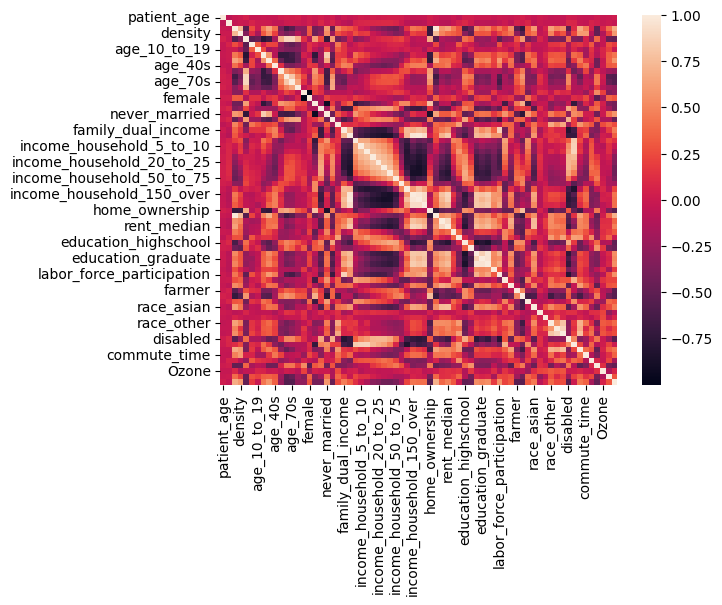

In [ ]:
# plot correlation
sns.heatmap(train_corr)

In [4]:
train_df.head()

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,475714,NaN,MEDICAID,CA,924,84,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,349367,White,COMMERCIAL,CA,928,62,F,28.49,C50411,Malig neoplm of upper-outer quadrant of right ...,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,138632,White,COMMERCIAL,TX,760,43,F,38.09,C50112,Malignant neoplasm of central portion of left ...,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,617843,White,COMMERCIAL,CA,926,45,F,NaN,C50212,Malig neoplasm of upper-inner quadrant of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,817482,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0


Race distribution in training data: patient_race
White       0.278010
Black       0.081822
Hispanic    0.064234
Other       0.052921
Asian       0.028281
Name: count, dtype: float64

Percentage of race NaN values: 0.4947311328064466



Text(0.5, 0, 'race')

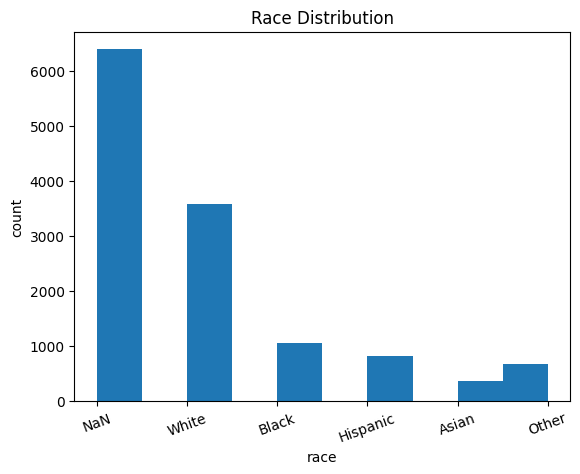

In [28]:
# sensitive populations we'll be looking at - race, age, region, payment type
# calc percentage of each race type
total_len = len(train_df)

print("Race distribution in training data:", train_df.patient_race.value_counts()/total_len)
print()
print("Percentage of race NaN values:", (total_len-train_df.patient_race.value_counts().sum())/total_len)
print()

# distribution graph
race = []
for i in train_df['patient_race']:
  if i == "White":
    race.append(1)
  elif i == "Black":
    race.append(2)
  elif i == "Hispanic":
    race.append(3)
  elif i == "Asian":
    race.append(4)
  elif i == "Other":
    race.append(5)
  else:
    race.append(0)

plt.hist(race)
plt.xticks([0, 1, 2, 3, 4, 5], ['NaN', 'White', 'Black', 'Hispanic', 'Asian', 'Other'], rotation=20)
plt.title('Race Distribution')
plt.ylabel('count')
plt.xlabel('race')

Age distribution in training data: patient_age
0    0.694948
1    0.305052
Name: count, dtype: float64
where -1 is NaN, 0 is less than 65, and 1 is 65+



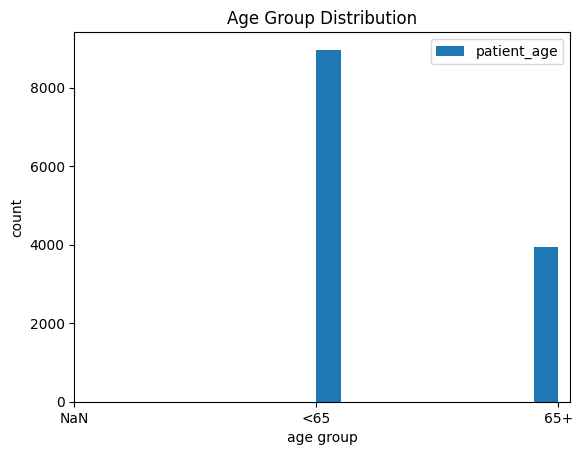

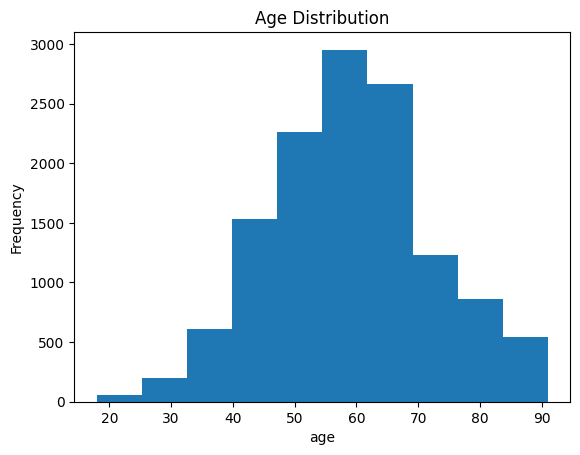

In [38]:
# calc percentage of each age type (older/younger than 65)
age = []
for i in train_df['patient_age']:
  if i >= 65:
    age.append(1)
  elif i < 65:
    age.append(0)
  else:
    age.append(-1)

age = pd.DataFrame(age, columns=['patient_age'])

print("Age distribution in training data:", age.patient_age.value_counts()/total_len)
print("where -1 is NaN, 0 is less than 65, and 1 is 65+")
print()

# distribution graph - separated age
age.plot.hist()
plt.xticks([-1,0,1], ['NaN', '<65', '65+'])
plt.ylabel('count')
plt.xlabel('age group')
plt.title('Age Group Distribution')
plt.show()

# distribution graph - all age
train_df.patient_age.plot.hist()
plt.xlabel('age')
plt.title('Age Distribution')
plt.show()

Region distribution in training data: Region
South        0.303657
West         0.289400
Midwest      0.282814
Northeast    0.120099
Name: count, dtype: float64

Percentage of region NaN values: 0.004029133736246707



Text(0.5, 0, 'region')

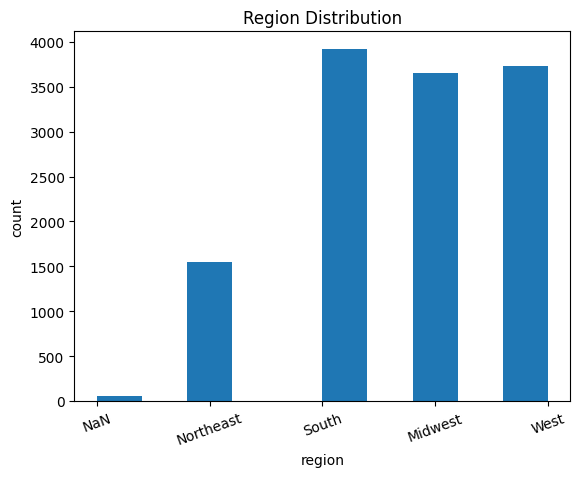

In [41]:
# calc percentage of each region type
print("Region distribution in training data:", train_df.Region.value_counts()/total_len)
print()
print("Percentage of region NaN values:", (total_len-train_df.Region.value_counts().sum())/total_len)
print()

# distribution graph
region = []
for i in train_df['Region']:
  if i == "Northeast":
    region.append(1)
  elif i == "South":
    region.append(2)
  elif i == "Midwest":
    region.append(3)
  elif i == "West":
    region.append(4)
  else:
    region.append(0)

plt.hist(region)
plt.xticks([0, 1, 2, 3, 4], ['NaN', 'Northeast', 'South', 'Midwest', 'West'], rotation=20)
plt.title('Region Distribution')
plt.ylabel('count')
plt.xlabel('region')

Payer type distribution in training data: payer_type
COMMERCIAL            0.467380
MEDICAID              0.199055
MEDICARE ADVANTAGE    0.193863
Name: count, dtype: float64

Percentage of payer type NaN values: 0.1397024639702464



Text(0.5, 0, 'payer type')

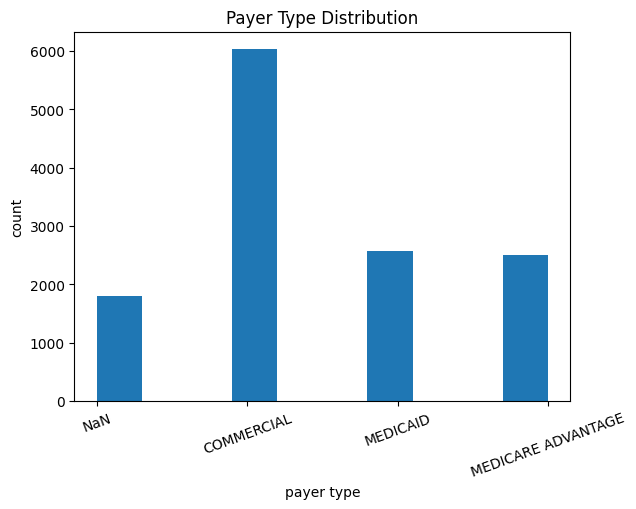

In [44]:
# calc percentage of each payment type
print("Payer type distribution in training data:", train_df.payer_type.value_counts()/total_len)
print()
print("Percentage of payer type NaN values:", (total_len-train_df.payer_type.value_counts().sum())/total_len)
print()

# distribution graph
pay = []
for i in train_df['payer_type']:
  if i == "COMMERCIAL":
    pay.append(1)
  elif i == "MEDICAID":
    pay.append(2)
  elif i == "MEDICARE ADVANTAGE":
    pay.append(3)
  else:
    pay.append(0)

plt.hist(pay)
plt.xticks([0, 1, 2, 3], ['NaN', 'COMMERCIAL', 'MEDICAID', 'MEDICARE ADVANTAGE'], rotation=20)
plt.title('Payer Type Distribution')
plt.ylabel('count')
plt.xlabel('payer type')